<a href="https://colab.research.google.com/github/leejungp2/dl-study/blob/main/260328_03_pytorch_computer_vision_exercise_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercise

## Resources

1. These exercises/solutions are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Sun May 10 00:48:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             29W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

> 현재 산업에서 컴퓨터 비전이 사용되는 3가지 분야는 무엇인가?


1. 자율주행 자동차  
   - 예: Tesla는 도로 상황을 인식하기 위해 컴퓨터 비전을 사용  
   - 참고: https://youtu.be/j0z4FweCy4M

2. 의료 영상  
   - 예: X-ray 해석을 돕기 위해 컴퓨터 비전 사용  
   - Google은 장 내 폴립 탐지에도 활용  
   - 참고: https://ai.googleblog.com/2021/08/improved-detection-of-elusive-polyps.html

3. 보안  
   - 예: 집에 침입자가 있는지 감지하는 데 컴퓨터 비전 사용  
   - 참고: https://store.google.com/au/product/nest_cam_battery?hl=en-GB


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

- 오버피팅은 시험을 위해 암기만 하고, 조금만 다른 문제가 나오면 풀지 못하는 것과 같음

- 즉, 모델이 학습 데이터를 *너무 잘* 학습해서 새로운 데이터에는 일반화되지 않는 상태


## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

See this article for some ideas: https://elitedatascience.com/overfitting-in-machine-learning


오버피팅을 방지하는 3가지 방법:

1. **정규화 기법 (Regularization techniques)**  
   - 신경망에서 [dropout](https://en.wikipedia.org/wiki/Dilution_(neural_networks))을 사용할 수 있음  
   - dropout은 일부 뉴런을 무작위로 제거하여  
     나머지 뉴런이 더 일반화된 패턴을 학습하도록 도움

2. **다른 모델 사용 (Use a different model)**  
   - 현재 모델이 너무 복잡할 수 있음 (레이어가 너무 많음)  
   - 일부 레이어를 제거하여 단순화 가능  
   - 또는 문제에 더 적합한 다른 모델 선택 가능  
   - [transfer learning](https://en.wikipedia.org/wiki/Transfer_learning)도 활용 가능

3. **데이터 노이즈 감소 / 데이터 정제 / 데이터 증강 사용**  
   - 모델이 데이터뿐 아니라 노이즈까지 암기할 수 있음  
   - 해결 방법  
     - 데이터 정제 (노이즈 제거)  
     - 또는 데이터 증강을 통해 인위적으로 다양성 증가

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

> CNN Explainer 웹사이트에 접속하여 20분 동안 내용을 읽고 여기저기 클릭해 보세요. 웹사이트의 "upload" 버튼을 사용해 직접 준비한 이미지를 업로드해 보세요. 이미지가 CNN의 각 레이어를 통과할 때 내부 데이터가 어떻게 변하는지 직접 관찰해 보세요.

The CNN explainer website is a great insight into all of the nuts and bolts of a convolutional neural network.

## 1. CNN (Convolutional Neural Network) 정의
*   **분류기(Classifier):** 데이터 포인트에 클래스 레이블을 할당하는 알고리즘 (예: 이미지 내 객체를 새, 비행기로 분류).
*   **신경망(Neural Network):** 데이터의 패턴을 인식하는 알고리즘으로, 레이어(Layer)로 구성된 뉴런들의 집합.
*   **특징:** 이미지 및 이미지와 유사한 데이터로부터 학습하는 데 최적화된 '합성곱 레이어'를 사용함.

## 2. 기본 구성 요소 (Building Blocks)
*   **Tensor (텐서):** n차원 행렬. CNN 내부에서는 주로 3차원 텐서 형태를 가짐.
*   **Neuron (뉴런):** 여러 입력을 받아 하나의 출력을 내놓는 함수. 출력은 활성화 맵(Activation Map)으로 시각화됨.
*   **Layer (레이어):** 동일한 하이퍼파라미터를 가진 뉴런들의 집합.
*   **Kernel Weights & Biases:** 학습 단계에서 조정되는 값으로, 노란색 → 초록색 색상 척도로 표현됨.
*   **Differentiable Score Function:** 출력층에서 클래스 점수(Class Scores)로 표현되는 함수.



---

## 3. 주요 레이어별 기능 (Layer Functions)

### **① Input Layer (입력층)**
*   **데이터 형태:** RGB 이미지 입력 시 Red, Green, Blue의 3개 채널로 구성.
*   **시각화:** 각 채널의 픽셀 값이 숫자로 표현됨.

### **② Convolutional Layer (합성곱 레이어)**
*   **핵심 역할:** 학습된 커널(가중치)을 통해 이미지의 특징(Features)을 추출.
*   **연산 방식:** 이전 레이어의 출력과 고유 커널 사이의 **요소별 점곱(Elementwise dot product)** 수행 후 편향(Bias)을 더함.
*   **연결성:** Tiny VGG에서는 이전 레이어의 모든 뉴런과 연결된 '완전 연결(Fully-connected)' 구조를 가짐.



### **③ Activation Function (ReLU)**
*   **비선형성(Non-linearity):** 복잡한 결정 경계를 만들기 위해 필수적임 (없으면 깊은 구조가 무의미해짐).
*   **연산:** $f(x) = \max(0, x)$ (음수는 0으로, 양수는 그대로 유지).
*   **장점:** 시그모이드 등 다른 함수보다 학습 속도가 빠름.

### **④ Pooling Layer (풀링층)**
*   **목적:** 공간적 크기를 점진적으로 줄여 파라미터 수와 계산량을 감소시키고 과적합을 방지.
*   **Max-Pooling:** 지정된 커널 영역에서 가장 큰 값만 선택.
*   **효과:** Tiny VGG(2x2 커널, Stride 2) 기준, 활성화 값의 75%를 버려 효율성을 높임.



### **⑤ Flatten Layer (플래튼 레이어)**
*   **역할:** 3차원 텐서를 1차원 벡터로 변환 (예: 5x5x2 → 50).
*   **필요성:** 추출된 특징을 소프트맥스 함수를 통해 최종 분류하기 위한 준비 단계.

### **⑥ Softmax Layer (소프트맥스)**
*   **확률화:** 모델 출력의 총합이 1이 되도록 스케일링하여 확률로 변환.
*   **차별점:** 단순 정규화와 달리 최대값(argmax)을 더 강조하면서도 미분 가능한 형태로 근사함.

---

## 4. 하이퍼파라미터 (Hyperparameters)
*   **Padding (패딩):** 활성화 맵 가장자리에 0을 추가하여 공간적 크기를 보존하고 경계 데이터를 보호함.
*   **Kernel Size (커널 크기):** 입력 위를 미끄러지는 창의 크기. 작은 커널은 국소적 특징을 세밀하게 추출함.
*   **Stride (스트라이드):** 커널이 한 번에 이동하는 픽셀 수. 작을수록 더 많은 데이터를 추출하지만 출력층이 커짐.

---

## 5. 학습 모델: Tiny VGG
*   **특징:** 실제 최첨단(SOTA) CNN과 동일한 레이어 및 연산을 사용하지만 규모가 작아 입문에 최적화됨.
*   **구현:** TensorFlow.js를 통해 브라우저 내 GPU 가속으로 실시간 시각화 구현.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [ ]:
import torchvision
from torchvision import datasets

from torchvision import transforms

In [ ]:
# Get the MNIST train dataset [C, H, W] 구조
train_data = datasets.MNIST(root=".", # 저장 경로 지정
                            train=True, # False일 경우 테스트 데이터(1만개)만 가져옴. true일 경우 훈련 데이터(6만개) 가져옴.
                            download=True,
                            transform=transforms.ToTensor()) # do we want to transform the data as we download it? 0~1사이의 텐서로 변환해줌

# Get the MNIST test dataset
test_data = datasets.MNIST(root=".",
                           train=False,
                           download=True,
                           transform=transforms.ToTensor())

In [ ]:
train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: .
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: .
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# Data is in tuple form (image, label) 가장 첫 번째 데이터 꺼내어 숫자 정도 및 레이블 확인
img = train_data[0][0] # 이미지, 정답
label = train_data[0][1] # 첫 번째 샘플 묶음에서 정답 레이블 변수에 담음
print(f"Image:\n {img}")
print(f"Label:\n {label}")

## 출력 해석
# 0은 검정색 부분
# 0 이상은 글씨 부분
# 28행 28열 형태
# label: 숫자 5 나옴

Image:
 tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
# Check out the shapes of our data
print(f"Image shape: {img.shape} -> [color_channels, height, width] (CHW)")
print(f"Label: {label} -> no shape, due to being integer")

"""
- 1 (color_channels): 흑백 이미지임을 의미합니다. RGB 컬러라면 3이었겠지만, MNIST는 단순한 흑백이라 채널이 1개입니다.
- 28 (height): 이미지의 세로 높이가 28픽셀입니다.
- 28 (width): 이미지의 가로 너비가 28픽셀입니다.
CHW 형식: PyTorch는 관례적으로 [Channel, Height, Width] 순서로 데이터를 처리합니다. (Tensorflow 등 다른 프레임워크와 순서가 다를 수 있으니 꼭 확인해야 함!)
"""

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width] (CHW)
Label: 5 -> no shape, due to being integer


'\n- 1 (color_channels): 흑백 이미지임을 의미합니다. RGB 컬러라면 3이었겠지만, MNIST는 단순한 흑백이라 채널이 1개입니다.\n- 28 (height): 이미지의 세로 높이가 28픽셀입니다.\n- 28 (width): 이미지의 가로 너비가 28픽셀입니다.\nCHW 형식: PyTorch는 관례적으로 [Channel, Height, Width] 순서로 데이터를 처리합니다. (Tensorflow 등 다른 프레임워크와 순서가 다를 수 있으니 꼭 확인해야 함!)\n'

> 참고: 머신러닝에서 이미지를 표현하는 데 합의된 두 가지 주요 방식이 있습니다.

1. Color channels first (채널 우선): [color_channels, height, width] (CHW)

- 설명: 색상 채널(R, G, B 등) 정보를 가장 앞에 둡니다.

- 표준: PyTorch의 기본 방식입니다 (2022년 4월 기준).

2. Color channels last (채널 마지막): [height, width, color_channels] (HWC)

- 설명: 이미지의 가로, 세로 크기를 먼저 쓰고 색상 채널 정보를 마지막에 둡니다.

- 표준: Matplotlib(시각화 라이브러리)이나 TensorFlow의 기본 방식입니다 (2022년 4월 기준).

In [ ]:
# Get the class names from the dataset
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])


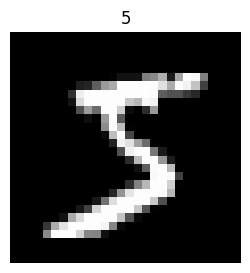

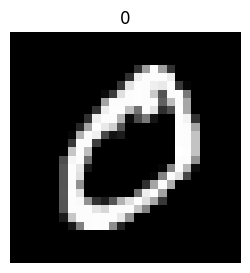

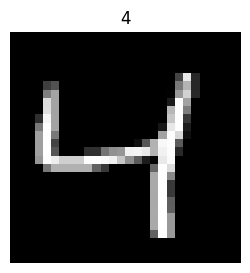

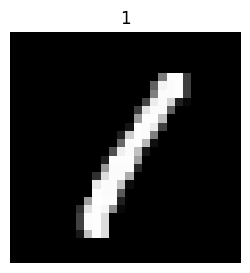

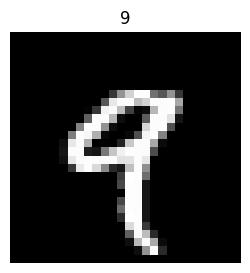

In [ ]:
import matplotlib.pyplot as plt
for i in range(5): # 0~4번까지 총 5개의 샘플을 반복해서 가져오기
  img = train_data[i][0] # 1, 28, 28 모양의 이미지 텐서 가져오기
  print(img.shape)
  img_squeeze = img.squeeze() # 크기가 1인 차원 제거
  print(img_squeeze.shape)
  label = train_data[i][1]
  plt.figure(figsize=(3, 3))
  plt.imshow(img_squeeze, cmap="gray") # 2차원 숫자 배열을 흑백 이미지로 그림
  plt.title(label)
  plt.axis(False); # 눈금 숨기기

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [ ]:
# Create train dataloader: MNIST 훈련/테스트 데이터셋을 PyTorch의 DataLoader로 변환\
"""
DataLoader 역할:
- 데이터를 배치(batch) 단위로 나눠줌 (batch_size=32)
- 학습 시 셔플(shuffle) 해서 모델이 순서에 치우치지 않게 함
- 자동으로 mini-batch를 만들어서 모델 학습을 효율적으로 만들어줌
"""

# torch.utils.data에서 DataLoader 클래스를 불러옴
from torch.utils.data import DataLoader

# Create train dataloader
# MNIST 훈련 데이터셋(train_data)을 DataLoader로 감싸서 생성함
train_dataloader = DataLoader(
    dataset=train_data,      # 사용할 데이터셋 지정
    batch_size=32,           # 한 번에 32개씩 배치로 묶음
    shuffle=True             # 매 epoch마다 데이터를 랜덤으로 섞음 (학습 시 필수)
)

# MNIST 테스트 데이터셋(test_data)을 DataLoader로 생성함
test_dataloader = DataLoader(
    dataset=test_data,       # 평가용 데이터셋 지정
    batch_size=32,           # 배치 크기는 훈련과 동일하게 설정
    shuffle=False            # 테스트 데이터는 순서를 섞지 않음
)

In [ ]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c59288c2a50>,
 <torch.utils.data.dataloader.DataLoader at 0x7c59288ee270>)

In [ ]:
for sample in next(iter(train_dataloader)): # iterable로 바꾸고 next로 그 중 한 묶음(첫 번째 배치)만 꺼내오기
  print(sample.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


<결과값>
- 첫 번째 텐서 → torch.Size([32, 1, 28, 28])
  - 32: 배치 크기 (한 번에 32개의 이미지를 처리)
  - 1: 채널 수 (흑백 이미지이므로 1채널)
  - 28, 28: 이미지 높이와 너비 (MNIST는 28×28 픽셀)

- 두 번째 텐서 → torch.Size([32])
  - 32: 배치 크기
  - 각 이미지에 대응하는 정답 레이블 (0~9 사이의 숫자)

In [ ]:
len(train_dataloader), len(test_dataloader) # len(dataloader): 전체 배치 개수
# 출력 결과: 배치 개수

(1875, 313)

- train_dataloader : 배치 개수 1875개
  
  (계산 : 60,000 ÷ 32 = 1,875)

- test_dataloader : 배치 개수 313개

  (계산 : 10,000 ÷ 32 = 312.5 → 올림)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

> MNIST 데이터셋에 사용할 TinyVGG 구조의 CNN 모델(model_2)을 정의

In [ ]:
from torch import nn

# TinyVGG 스타일의 CNN 모델 정의 (MNIST용)
class MNIST_model(torch.nn.Module):
    """Model capable of predicting on MNIST dataset.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        # 첫 번째 Convolution Block
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,      # 입력 채널 (MNIST는 흑백이므로 1)
                      out_channels=hidden_units,    # 출력 채널 수 (설정값)
                      kernel_size=3,                # 3x3 필터 사용
                      stride=1,                     # 1칸씩 이동
                      padding=1),                   # 가장자리 패딩 (크기 유지)
            nn.ReLU(),                            # 활성화 함수
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)           # 2x2 맥스풀링으로 특징 맵 크기 절반으로 줄임
        )

        # 두 번째 Convolution Block
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)           # 다시 한번 특징 맵 크기 절반으로 줄임
        )

        # 분류기 (Classifier) 부분
        self.classifier = nn.Sequential(
            nn.Flatten(),                         # 2D 특징 맵을 1D 벡터로 펼침
            nn.Linear(in_features=hidden_units*7*7,  # conv_block_2를 통과한 후 크기: 7x7
                      out_features=output_shape)     # 출력 클래스 수 (MNIST는 10)
        )

    # 순전파(forward) 정의
    def forward(self, x):
        x = self.conv_block_1(x)      # 첫 번째 Conv Block 통과
        # print(f"Output shape of conv block 1: {x.shape}")

        x = self.conv_block_2(x)      # 두 번째 Conv Block 통과
        # print(f"Output shape of conv block 2: {x.shape}")

        x = self.classifier(x)        # Flatten 후 Linear로 최종 예측
        # print(f"Output shape of classifier: {x.shape}")

        return x

<모델 구조 요약>

- conv_block_1 → conv_block_2 → classifier
- 입력: [batch, 1, 28, 28]
- 출력: [batch, 10] (0~9 숫자 확률)

In [ ]:
device

'cuda'

In [ ]:
# MNIST_model 클래스를 사용해 실제 모델 인스턴스를 생성함
model = MNIST_model(input_shape=1, # input_shape=1  → MNIST는 흑백 이미지이므로 채널이 1개
                    hidden_units=10, # hidden_units=10 → 각 Conv 레이어에서 사용할 필터(채널) 개수
                    output_shape=10).to(device)   # 모델을 GPU 또는 CPU로 이동, output_shape=10 → MNIST는 0~9까지 10개의 클래스로 분류

# 모델 구조를 출력해서 확인함
model

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

1. conv_block_1

Conv2d(1 → 10): 1채널(흑백) 입력 → 10개의 특징맵 생성

Conv2d(10 → 10): 특징을 더 잘 뽑기 위한 두 번째 컨볼루션

MaxPool2d: 이미지 크기를 28×28 → 14×14로 줄임

2. conv_block_2

Conv2d(10 → 10) × 2: 다시 특징 추출

MaxPool2d: 이미지 크기를 14×14 → 7×7로 줄임

3. classifier

Flatten(): [32, 10, 7, 7] 형태를 [32, 490] (10×7×7=490)으로 펼침

Linear(490 → 10): 490개의 특징을 최종 10개 클래스(0~9)로 변환


<요약>

총 파라미터 수: hidden_units=10으로 설정했기 때문에 비교적 가벼운 모델

입력 이미지 크기: 28×28×1 → 최종 특징맵 7×7×10 → Flatten 후 490 차원

출력: 10개 (각 숫자에 대한 확률)

In [ ]:
# Check out the model state dict to find out what patterns our model wants to learn
# model.state_dict()

In [ ]:
# dummy(가짜) 데이터를 만들어 모델이 제대로 동작하는지 테스트함
# 실제 학습 전에 모델의 input/output shape을 확인하는 용도

# 28x28 크기의 랜덤 이미지를 생성 (MNIST와 같은 크기)
dummy_x = torch.rand(size=(1, 28, 28))   # shape: [1, 28, 28]

# unsqueeze(dim=0)으로 배치 차원을 추가 → [1, 1, 28, 28] 형태로 만듦
dummy_x = dummy_x.unsqueeze(dim=0).to(device)

# 모델에 dummy 데이터를 넣어 forward pass 실행
model(dummy_x)

tensor([[ 0.0274, -0.0198, -0.0394,  0.0166, -0.0253, -0.0461, -0.0342, -0.0035,
          0.0699, -0.0087]], device='cuda:0', grad_fn=<AddmmBackward0>)

<결과값 해석>

출력 shape: [1, 10]

- 1 = 배치 크기 (dummy 데이터 1장)
- 10 = MNIST의 출력 클래스 개수 (0부터 9까지)

값의 의미:
현재는 모델이 랜덤 초기화 상태이기 때문에 의미 없는 숫자들이 나옵니다.
이 값들은 각 숫자(0~9)에 대한 logits (확률이 되기 전의 raw 점수)입니다.
아직 학습이 안 되었으므로 값이 거의 0에 가깝고, 음수/양수가 섞여 있습니다.

grad_fn=<AddmmBackward0>:
PyTorch가 자동 미분을 위해 기록한 그래디언트 함수 (학습 가능하다는 뜻)

In [ ]:
# conv_block_2를 통과한 후의 특징 맵(shape)을 dummy 데이터로 만들어 확인함
# 실제 모델에서 conv_block_2 출력이 [batch, 10, 7, 7] 형태이기 때문에 이렇게 테스트

# [1, 10, 7, 7] 형태의 dummy 데이터 생성 (배치=1, 채널=10, 높이=7, 너비=7)
dummy_x_2 = torch.rand(size=(1, 10, 7, 7))

# shape 확인
dummy_x_2.shape

torch.Size([1, 10, 7, 7])

In [ ]:
# nn.Flatten() 레이어를 생성 (2D 특징맵을 1D로 펼쳐주는 역할)
flatten_layer = nn.Flatten()

# dummy 데이터를 Flatten 레이어에 통과시켜 shape 변화 확인
flatten_layer(dummy_x_2).shape

torch.Size([1, 490])

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [ ]:
%%time
# 위 매직 명령어는 셀 전체 실행 시간을 측정해줌 (CPU 학습에 얼마나 걸리는지 확인용)

from tqdm.auto import tqdm   # 학습 진행 상황을 프로그레스 바로 보여줌

# CPU에서 학습할 모델을 새로 생성함
model_cpu = MNIST_model(input_shape=1,
                        hidden_units=10,
                        output_shape=10).to("cpu")

# 손실 함수와 옵티마이저 설정
loss_fn = nn.CrossEntropyLoss()                    # 다중 분류 문제이므로 CrossEntropyLoss 사용
optimizer = torch.optim.SGD(model_cpu.parameters(), lr=0.1)   # SGD 옵티마이저, 학습률 0.1

### Training loop
epochs = 5   # 총 5번의 에폭 학습

# tqdm으로 학습 진행 상황을 시각적으로 보여줌
for epoch in tqdm(range(epochs)):
    train_loss = 0   # 한 에폭 동안의 총 train loss를 누적할 변수

    # ==================== 훈련 모드 ====================
    for batch, (X, y) in enumerate(train_dataloader):   # 배치 단위로 데이터 불러옴
        model_cpu.train()          # 모델을 훈련 모드로 설정

        # 데이터와 레이블을 CPU로 이동 (이미 CPU에 있지만 명시적으로 작성)
        X, y = X.to("cpu"), y.to("cpu")

        # Forward pass (순전파)
        y_pred = model_cpu(X)

        # Loss 계산
        loss = loss_fn(y_pred, y)
        train_loss += loss          # 배치 loss를 누적

        # Optimizer zero grad (기울기 초기화)
        optimizer.zero_grad()

        # Backward pass (역전파)
        loss.backward()

        # Optimizer step (가중치 업데이트)
        optimizer.step()

    # 평균 train loss 계산 (전체 배치 수로 나눔)
    train_loss /= len(train_dataloader)

    ### ==================== 테스트 모드 ====================
    test_loss_total = 0

    model_cpu.eval()                    # 모델을 평가 모드로 전환
    with torch.inference_mode():        # gradient 추적을 끔 → 메모리 절약 + 속도 향상

        for batch, (X_test, y_test) in enumerate(test_dataloader):
            X_test, y_test = X_test.to("cpu"), y_test.to("cpu")

            test_pred = model_cpu(X_test)               # 예측
            test_loss = loss_fn(test_pred, y_test)      # 테스트 loss 계산

            test_loss_total += test_loss

        # 평균 test loss 계산
        test_loss_total /= len(test_dataloader)

    # 매 에폭마다 결과 출력
    print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss_total:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.323 | Test loss: 0.059
Epoch: 1 | Loss: 0.075 | Test loss: 0.049
Epoch: 2 | Loss: 0.057 | Test loss: 0.045
Epoch: 3 | Loss: 0.049 | Test loss: 0.047
Epoch: 4 | Loss: 0.043 | Test loss: 0.051
CPU times: user 3min 10s, sys: 1.06 s, total: 3min 11s
Wall time: 3min 16s


In [ ]:
%%time
from tqdm.auto import tqdm

# GPU 사용 가능 여부에 따라 device 설정 (cuda 또는 cpu)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Train on GPU
# GPU에서 학습할 모델 생성 및 device로 이동
model_gpu = MNIST_model(input_shape=1,
                        hidden_units=10,
                        output_shape=10).to(device)

# Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()                                      # 다중 분류 문제이므로 CrossEntropyLoss 사용
optimizer = torch.optim.SGD(model_gpu.parameters(), lr=0.1)         # SGD 옵티마이저, 학습률 0.1

# Training loop
epochs = 5
for epoch in tqdm(range(epochs)):
    train_loss = 0
    model_gpu.train()                                                # 모델을 학습 모드로 설정

    for batch, (X, y) in enumerate(train_dataloader):
        # Put data on target device
        X, y = X.to(device), y.to(device)                            # 데이터를 GPU(또는 CPU)로 이동

        # Forward pass
        y_pred = model_gpu(X)                                        # 순전파

        # Loss calculation
        loss = loss_fn(y_pred, y)
        train_loss += loss                                           # 배치별 loss 누적

        # Optimizer zero grad
        optimizer.zero_grad()                                        # 기울기 초기화

        # Loss backward
        loss.backward()                                              # 역전파 (기울기 계산)

        # Step the optimizer
        optimizer.step()                                             # 가중치 업데이트

    # Adjust train loss to number of batches
    train_loss /= len(train_dataloader)                              # 평균 train loss 계산

    ### Testing loop
    test_loss_total = 0
    # Put model in eval mode and turn on inference mode
    model_gpu.eval()                                                 # 평가 모드 전환
    with torch.inference_mode():                                     # gradient 추적 OFF (추론 모드)
        for batch, (X_test, y_test) in enumerate(test_dataloader):
            # Make sure test data on target device
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred = model_gpu(X_test)
            test_loss = loss_fn(test_pred, y_test)

            test_loss_total += test_loss

        # Adjust test loss total for number of batches
        test_loss_total /= len(test_dataloader)                      # 평균 test loss 계산

    # Print out what's happening
    print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss_total:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.299 | Test loss: 0.073
Epoch: 1 | Loss: 0.072 | Test loss: 0.049
Epoch: 2 | Loss: 0.055 | Test loss: 0.046
Epoch: 3 | Loss: 0.047 | Test loss: 0.038
Epoch: 4 | Loss: 0.041 | Test loss: 0.042
CPU times: user 58.4 s, sys: 549 ms, total: 59 s
Wall time: 1min


<CPU 코드 vs GPU 코드 주요 차이점>

| 항목                        | CPU 버전                                      | GPU 버전                                          | 설명 |
|-----------------------------|-----------------------------------------------|---------------------------------------------------|------|
| **device 설정**             | `"cpu"`로 직접 고정                            | `device = "cuda" if torch.cuda.is_available() else "cpu"` | GPU가 있으면 자동으로 사용 |
| **모델 변수명**             | `model_cpu`                                   | `model_gpu`                                       | 변수명만 다름 |
| **모델 이동**               | `.to("cpu")`                                  | `.to(device)`                                     | device 변수 활용 |
| **`model.train()` 위치**    | 훈련 루프 **내부** (매 배치마다 호출)          | 훈련 루프 **외부** (에폭당 1번 호출)              | **가장 중요한 성능 차이** |
| **데이터 이동**             | `.to("cpu")`                                  | `.to(device)`                                     | device 변수 사용 |
| **train_loss 누적 방식**    | 동일                                          | 동일                                              | - |
| **테스트 루프 구조**        | 동일                                          | 동일                                              | - |
| **전체 코드 효율성**        | 다소 비효율적                                  | 더 효율적                                         | GPU 버전이 실무에 가까움 |

<핵심 차이 요약>

1. **가장 중요한 차이**
   - GPU 버전은 `model_gpu.train()`을 **for문 바깥**에 배치하여 불필요한 반복 호출을 제거함

2. **device 처리**
   - GPU 버전은 `device` 변수를 사용해 **GPU/CPU 자동 전환**이 가능

3. **실용성**
   - GPU 버전이 더 깔끔하고, 실제 학습에서 권장되는 방식

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

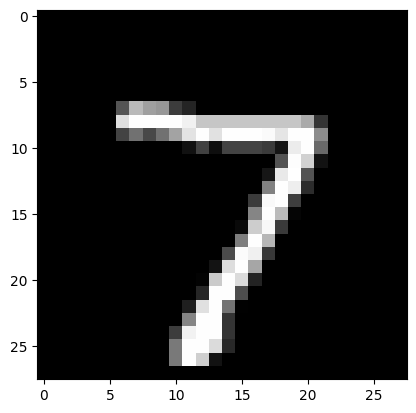

In [ ]:
# Make predictions with the trained model
plt.imshow(test_data[0][0].squeeze(), cmap="gray")
# 테스트 데이터셋의 첫 번째 샘플 이미지를 시각화함
# test_data[0]     → 첫 번째 샘플 (이미지, 레이블) 튜플
# test_data[0][0]  → 이미지 텐서
# squeeze()        → 채널 차원([1, 28, 28] → [28, 28]) 제거

In [ ]:
# Logits -> Prediction probabilities -> Prediction labels
# logits(원시 점수) → 확률 → 최종 예측 레이블로 변환하는 과정

# 모델에 첫 번째 테스트 이미지를 넣어 예측 수행
# test_data[0][0]     → 첫 번째 테스트 이미지
# unsqueeze(dim=0)    → 배치 차원 추가 [1, 1, 28, 28] 형태로 만듦
# .to(device)         → 모델과 같은 device(GPU)로 이동
model_pred_logits = model_gpu(test_data[0][0].unsqueeze(dim=0).to(device))

# softmax를 적용하여 logits을 확률(probabilities)로 변환
model_pred_probs = torch.softmax(model_pred_logits, dim=1)

# 가장 높은 확률을 가진 클래스를 예측 레이블로 선택
model_pred_label = torch.argmax(model_pred_probs, dim=1)

# 최종 예측 결과 출력
model_pred_label ## 모델이 첫 번째 test img를 7로 예측

tensor([7], device='cuda:0')

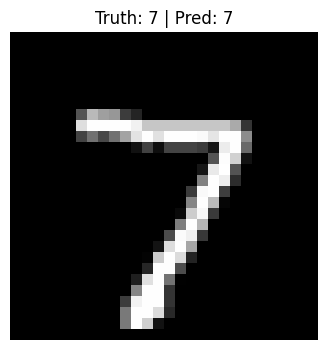

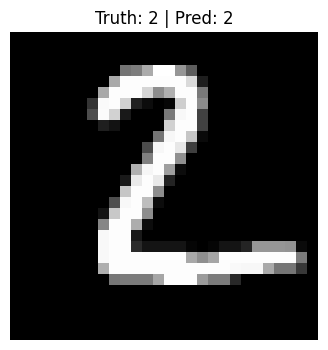

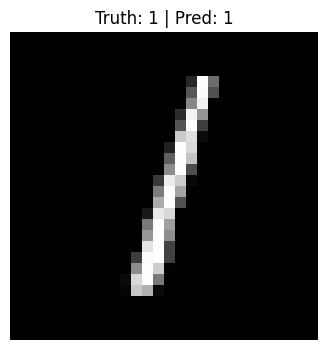

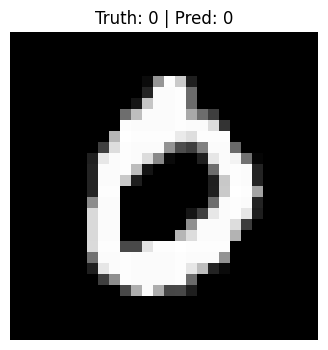

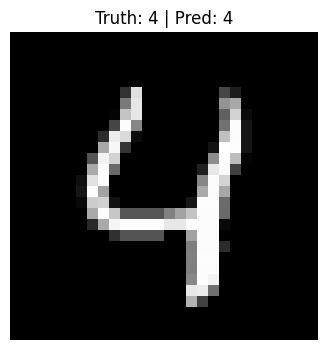

In [ ]:
# 시각화할 이미지 개수를 5개로 설정
num_to_plot = 5

# 5개의 테스트 이미지를 순서대로 가져와 예측하고 시각화
for i in range(num_to_plot):
    # Get image and labels from the test data
    # 테스트 데이터에서 i번째 이미지와 정답 레이블 가져오기
    img = test_data[i][0]      # 이미지 텐서
    label = test_data[i][1]    # 실제 정답 레이블 (Truth)

    # Make prediction on image
    # 모델을 사용해 예측 수행
    model_pred_logits = model_gpu(img.unsqueeze(dim=0).to(device))   # 배치 차원 추가 + GPU 이동
    model_pred_probs = torch.softmax(model_pred_logits, dim=1)       # logits → 확률 변환
    model_pred_label = torch.argmax(model_pred_probs, dim=1)         # 가장 높은 확률의 클래스 선택

    # Plot the image and prediction
    # 이미지와 예측 결과 시각화
    plt.figure(figsize=(4, 4))          # ← 이미지 크기 조정 (추가 추천)
    plt.imshow(img.squeeze(), cmap="gray")   # 채널 차원 제거 후 흑백으로 출력
    plt.title(f"Truth: {label} | Pred: {model_pred_label.cpu().item()}")
    plt.axis(False);                    # 축 숨기기

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [ ]:
!pip


Usage:   
  pip3 <command> [options]

Commands:
  install                     Install packages.
  download                    Download packages.
  uninstall                   Uninstall packages.
  freeze                      Output installed packages in requirements format.
  inspect                     Inspect the python environment.
  list                        List installed packages.
  show                        Show information about installed packages.
  check                       Verify installed packages have compatible dependencies.
  config                      Manage local and global configuration.
  search                      Search PyPI for packages.
  cache                       Inspect and manage pip's wheel cache.
  index                       Inspect information available from package indexes.
  wheel                       Build wheels from your requirements.
  hash                        Compute hashes of package archives.
  completion                  A helper c

In [ ]:
!apt

apt 2.4.14 (amd64)
Usage: apt [options] command

apt is a commandline package manager and provides commands for
searching and managing as well as querying information about packages.
It provides the same functionality as the specialized APT tools,
like apt-get and apt-cache, but enables options more suitable for
interactive use by default.

Most used commands:
  list - list packages based on package names
  search - search in package descriptions
  show - show package details
  install - install packages
  reinstall - reinstall packages
  remove - remove packages
  autoremove - Remove automatically all unused packages
  update - update list of available packages
  upgrade - upgrade the system by installing/upgrading packages
  full-upgrade - upgrade the system by removing/installing/upgrading packages
  edit-sources - edit the source information file
  satisfy - satisfy dependency strings

See apt(8) for more information about the available commands.
Configuration options and syntax is

In [ ]:
# See if torchmetrics exists, if not, install it
# torchmetrics와 mlxtend 라이브러리가 설치되어 있는지 확인하고, 없으면 설치하는 코드

try:
    # torchmetrics와 mlxtend를 import 시도
    import torchmetrics, mlxtend
    # 설치된 mlxtend 버전 출력
    print(f"mlxtend version: {mlxtend.__version__}")
    # mlxtend 버전이 0.19.0 이상인지 체크 (confusion matrix plotting에 필요)
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"

except:
    # 라이브러리가 없거나 버전이 낮으면 설치
    # -q : quiet 모드 (설치 과정 상세 출력 숨김)
    !pip install -q torchmetrics -U mlxtend

    # 설치 후 다시 import
    import torchmetrics, mlxtend
    # 설치된 mlxtend 버전 출력
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


In [ ]:
# 런타임 재시작 후 이 셀을 실행하여 필요한 패키지를 재설치
!pip install -q torchmetrics -U mlxtend
import torchmetrics, mlxtend
print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


In [ ]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.24.0


In [ ]:
# Make predictions across all test data
# 테스트 데이터 전체에 대해 모델의 예측을 수행하는 코드

from tqdm.auto import tqdm   # 진행 상황 바를 표시하기 위해 tqdm import

model_gpu.eval()             # 모델을 평가 모드(eval mode)로 전환

y_preds = []                 # 각 배치의 예측 결과를 저장할 리스트

# torch.inference_mode() 사용 → gradient 계산을 하지 않아 메모리와 속도 효율적
with torch.inference_mode():
    for batch, (X, y) in tqdm(enumerate(test_dataloader)):   # 테스트 데이터로더를 배치 단위로 순회
        # Make sure data on right device
        X, y = X.to(device), y.to(device)                    # 데이터를 GPU(또는 CPU)로 이동

        # Forward pass
        y_pred_logits = model_gpu(X)                          # 모델을 통한 logits 출력

        # Logits -> Pred probs -> Pred label
        # softmax로 확률 변환 → argmax로 최종 예측 클래스 선택
        y_pred_labels = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)

        # Append the labels to the preds list
        y_preds.append(y_pred_labels)                         # 예측 결과를 리스트에 추가

# 모든 배치의 예측 결과를 하나의 텐서로 합침
y_preds = torch.cat(y_preds).cpu()                            # GPU → CPU로 이동

# 전체 예측 개수 확인 (테스트 데이터 개수와 같아야 함)
len(y_preds)

0it [00:00, ?it/s]

10000

In [ ]:
# test_data.targets[:10], y_preds[:10]
# 실제 정답 레이블과 모델의 예측 레이블을 앞 10개만 비교해보는 코드

test_data.targets[:10], y_preds[:10]

(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]))

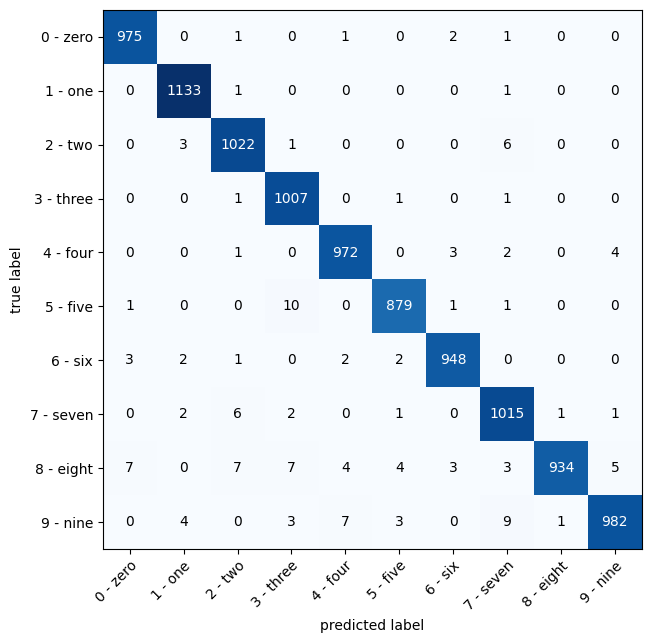

In [ ]:
from torchmetrics import ConfusionMatrix   # Confusion Matrix 계산을 위한 torchmetrics import
from mlxtend.plotting import plot_confusion_matrix   # Confusion Matrix를 예쁘게 시각화하기 위한 함수 import

# Setup confusion matrix
# 다중 분류용 Confusion Matrix 객체 생성
confmat = ConfusionMatrix(task="multiclass",
                          num_classes=len(class_names))   # 클래스 개수 = 10 (0~9)

# 실제 정답(target)과 모델의 예측(preds)을 넣어 Confusion Matrix 계산
confmat_tensor = confmat(preds=y_preds,
                         target=test_data.targets)

# Plot the confusion matrix
# 계산된 Confusion Matrix를 시각화
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),      # torch tensor → numpy 배열로 변환
    class_names=class_names,              # 클래스 이름 (['0','1','2',...,'9'])
    figsize=(10, 7)                       # 그래프 크기 설정
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

> Conv2d 레이어의 하이퍼파라미터 변화에 따른 출력 shape을 실험해보는 코드

In [ ]:
# [1, 3, 64, 64] 형태의 랜덤 텐서 생성
# 의미: 배치 1개, RGB 이미지(3채널), 64x64 크기
random_tensor = torch.rand([1, 3, 64, 64])
random_tensor.shape

torch.Size([1, 3, 64, 64])

In [ ]:
# nn.Conv2d 레이어 생성
conv_layer = nn.Conv2d(in_channels=3,      # 입력 채널 수 (RGB = 3)
                       out_channels=64,    # 출력 채널 수 (필터 개수)
                       kernel_size=3,      # 커널(필터) 크기 3x3
                       stride=2,           # 2칸씩 이동
                       padding=1)          # 가장자리에 1픽셀 패딩 추가

print(f"Random tensor original shape: {random_tensor.shape}")
# Conv2d 레이어에 random_tensor 통과
random_tensor_through_conv_layer = conv_layer(random_tensor)
print(f"Random tensor through conv layer shape: {random_tensor_through_conv_layer.shape}")

Random tensor original shape: torch.Size([1, 3, 64, 64])
Random tensor through conv layer shape: torch.Size([1, 64, 32, 32])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

> 훈련된 model_2 (TinyVGG 스타일 CNN)와 비슷한 구조의 모델을 사용해
FashionMNIST 데이터셋에 대한 예측을 수행하고, 모델이 틀리게 예측한 이미지들을 시각화한 후 분석하는 문제

1. FashionMNIST 데이터셋을 사용해 모델을 학습하거나 (또는 이미 학습된 모델 사용)
torchvision.datasets.FashionMNIST 사용

2. 테스트 데이터셋에 대해 예측을 수행

3. 모델이 잘못 예측한 이미지들을 시각화

실제 정답 레이블(True label)과 모델이 예측한 레이블(Pred label)을 함께 표시

최소 몇 개 이상 (보통 5~10개 권장)

4. 분석 질문에 답하기

모델이 틀린 이유가 모델링 오류(Modeling error) 인가?

아니면 데이터 자체의 문제(Data error) 인가?

특히 "Shirt" 와 "T-shirt/top" 같은 비슷한 클래스 때문에 혼동이 발생하는지 분석

In [ ]:
# Download FashionMNIST train & test
# FashionMNIST 데이터셋을 다운로드하고 로드하는 코드

from torchvision import datasets
from torchvision import transforms

# FashionMNIST 훈련 데이터셋 로드
fashion_mnist_train = datasets.FashionMNIST(
    root=".",                    # 데이터셋을 저장할 폴더 위치 (현재 디렉토리)
    download=True,               # 데이터셋이 없으면 자동으로 다운로드
    train=True,                  # 훈련 데이터셋 (60,000개)
    transform=transforms.ToTensor()  # 이미지를 Tensor로 변환
)

# FashionMNIST 테스트 데이터셋 로드
fashion_mnist_test = datasets.FashionMNIST(
    root=".",                    # 같은 폴더에 저장
    train=False,                 # 테스트 데이터셋 (10,000개)
    download=True,               # 데이터셋이 없으면 다운로드
    transform=transforms.ToTensor()  # 이미지를 Tensor로 변환
)

# 훈련 데이터와 테스트 데이터 개수 확인
len(fashion_mnist_train), len(fashion_mnist_test)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]


(60000, 10000)

In [ ]:
# Get the class names of the Fashion MNIST dataset
fashion_mnist_class_names = fashion_mnist_train.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# FashionMNIST 데이터셋을 데이터로더(DataLoader)로 변환
from torch.utils.data import DataLoader

# 훈련 데이터용 데이터로더 설정
fashion_mnist_train_dataloader = DataLoader(
    fashion_mnist_train,           # 학습에 사용할 원본 데이터셋
    batch_size=32,                 # 한 번에 모델에 넣을 데이터 개수 (32개씩 묶음)
    shuffle=True                   # 에폭마다 데이터 순서를 섞어 모델의 과적합 방지 및 학습 효율 향상
)

# 테스트 데이터용 데이터로더 설정
fashion_mnist_test_dataloader = DataLoader(
    fashion_mnist_test,            # 평가에 사용할 원본 데이터셋
    batch_size=32,                 # 한 번에 평가할 데이터 개수 (훈련과 동일하게 32개)
    shuffle=False                  # 평가 시에는 데이터 순서를 섞을 필요가 없으므로 False 설정
)

# 각 데이터로더에 포함된 총 배치(Batch)의 개수 확인
# 예: 전체 데이터가 60,000개이고 batch_size가 32라면 len은 1,875가 됨
len(fashion_mnist_train_dataloader), len(fashion_mnist_test_dataloader)

(1875, 313)

In [ ]:
## # Setup metrics 앞서 정의한 `MNIST_model` 클래스를 바탕으로 실제 모델 객체를 생성하고, 연산 장치(CPU/GPU)에 할당하는 과정
# model_2는 이전에 정의한 MNIST_model과 동일한 구조를 가짐
model_2 = MNIST_model(
    input_shape=1,       # 입력 데이터의 채널 수 (FashionMNIST는 흑백 이미지이므로 1)
    hidden_units=10,     # 은닉층(Hidden Layer) 내부에 배치될 뉴런(유닛)의 개수
    output_shape=10      # 출력할 클래스의 개수 (0~9까지 총 10개의 카테고리)
).to(device)             # 모델의 파라미터를 설정된 장치(CPU 또는 GPU)로 이동

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
# 손실 함수(Loss Function)와 옵티마이저(Optimizer) 설정
from torch import nn

# 다중 클래스 분류를 위한 손실 함수 설정 (FashionMNIST는 10개의 클래스)
# 내부적으로 Softmax 연산이 포함되어 있어 로짓(Logits)을 직접 입력받음
loss_fn = nn.CrossEntropyLoss()

# 모델의 파라미터를 업데이트할 옵티마이저 설정
# 확률적 경사 하강법(SGD)을 사용하며, 학습률(Learning Rate)은 0.01로 설정
optimizer = torch.optim.SGD(
    params=model_2.parameters(), # 업데이트할 모델의 가중치들
    lr=0.01                      # 가중치를 한 번에 얼마나 수정할지 결정하는 보폭
)

In [ ]:
## 이 코드는 앞서 정의한 함수들을 직접 사용하지 않고, 코드 내에서 학습(Training)과 평가(Testing) 과정을 한 번에 수행하는 전체 루프임. torchmetrics를 사용하여 정확도를 계산하는 것이 특징임.
# 성능 측정을 위한 라이브러리 및 정확도 함수 설정
from tqdm.auto import tqdm # 진행률 표시바 라이브러리
from torchmetrics import Accuracy # 파이토치 전용 성능 지표 라이브러리

# 정확도 계산 함수 설정 (다중 클래스 분류, 클래스 개수 지정)
acc_fn = Accuracy(task = 'multiclass', num_classes=len(fashion_mnist_class_names)).to(device)

# 전체 학습/테스트 루프 설정
epochs = 5 # 전체 데이터셋을 5번 반복 학습
for epoch in tqdm(range(epochs)):
  train_loss, test_loss_total = 0, 0 # 에폭별 손실 초기화
  train_acc, test_acc = 0, 0         # 에폭별 정확도 초기화

  ### --- Training 단계 --- ###
  model_2.train() # 모델을 학습 모드로 전환
  for batch, (X_train, y_train) in enumerate(fashion_mnist_train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device) # 데이터를 GPU/CPU로 이동

    # 1. Forward pass: 예측값 계산 및 손실 측정
    y_pred = model_2(X_train)
    loss = loss_fn(y_pred, y_train)
    train_loss += loss # 배치 손실 누적
    train_acc += acc_fn(y_pred, y_train) # 배치 정확도 누적 (torchmetrics 사용)

    # 2. 역전파 및 경사 하강법 (가중치 업데이트)
    optimizer.zero_grad() # 기울기 초기화
    loss.backward()       # 역전파: 기울기 계산
    optimizer.step()      # 가중치 업데이트

  # 에폭 당 평균 손실/정확도 계산 (누적치를 배치 개수로 나눔)
  train_loss /= len(fashion_mnist_train_dataloader)
  train_acc /= len(fashion_mnist_train_dataloader)

  ### --- Testing 단계 --- ###
  model_2.eval() # 모델을 평가 모드로 전환 (드롭아웃 등 비활성화)
  with torch.inference_mode(): # 기울기 계산 비활성화 (메모리 절약)
    for batch, (X_test, y_test) in enumerate(fashion_mnist_test_dataloader):
      X_test, y_test = X_test.to(device), y_test.to(device)

      # 1. Forward pass: 테스트 데이터 예측 및 손실 계산
      y_pred_test = model_2(X_test)
      test_loss = loss_fn(y_pred_test, y_test)
      test_loss_total += test_loss # 테스트 손실 누적

      # 2. 테스트 정확도 계산 및 누적
      test_acc += acc_fn(y_pred_test, y_test)

    # 에폭 당 평균 테스트 손실/정확도 계산
    test_loss_total /= len(fashion_mnist_test_dataloader)
    test_acc /= len(fashion_mnist_test_dataloader)

  # 매 에폭마다 결과 출력
  print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Train acc: {train_acc:.2f} | Test loss: {test_loss_total:.3f} | Test acc: {test_acc:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.373 | Train acc: 0.50 | Test loss: 214.279 | Test acc: 0.76
Epoch: 1 | Train loss: 0.565 | Train acc: 0.79 | Test loss: 166.247 | Test acc: 0.81
Epoch: 2 | Train loss: 0.500 | Train acc: 0.82 | Test loss: 155.581 | Test acc: 0.83
Epoch: 3 | Train loss: 0.459 | Train acc: 0.83 | Test loss: 146.858 | Test acc: 0.83
Epoch: 4 | Train loss: 0.429 | Train acc: 0.84 | Test loss: 140.189 | Test acc: 0.84


In [ ]:
# Make predictions with trained model_2
# 1. 학습된 model_2를 사용하여 예측 수행
test_preds = [] # 모든 배치에서의 예측값을 저장할 빈 리스트 생성
model_2.eval()  # 모델을 평가(추론) 모드로 설정

# 2. 기울기 계산을 끄고 추론 모드 진입 (메모리 효율 및 속도 향상)
with torch.inference_mode():
  # 테스트 데이터로더를 순회하며 진행바 표시
  for X_test, y_test in tqdm(fashion_mnist_test_dataloader):
    # 데이터를 장치(GPU/CPU)로 보낸 후 모델에 입력하여 로짓(logits) 계산
    y_logits = model_2(X_test.to(device))

    # 로짓을 확률값으로 변환 (Softmax) 후 가장 높은 확률의 인덱스(클래스) 추출
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_pred_labels = torch.argmax(y_pred_probs, dim=1)

    # 현재 배치의 예측 결과를 리스트에 추가
    test_preds.append(y_pred_labels)

# 3. 리스트에 담긴 여러 개의 배치 텐서들을 하나로 결합
# 시각화 라이브러리(Matplotlib)와의 호환성을 위해 결과를 CPU로 이동
test_preds = torch.cat(test_preds).cpu()

# 4. 처음 10개의 예측값과 전체 예측 개수 확인
test_preds[:10], len(test_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1, 1, 2, 1, 6, 4, 5, 7]), 10000)

In [ ]:
# 틀린 예측 결과의 인덱스(위치) 가져오기
import numpy as np

# np.where를 사용하여 예측값(test_preds)과 실제 정답(targets)이 일치하지 않는 지점을 찾음
# [0]을 붙이는 이유는 np.where가 튜플 형태를 반환하므로 인덱스 배열만 추출하기 위함
wrong_pred_indexes = np.where(test_preds != fashion_mnist_test.targets)[0]

# 총 몇 개의 데이터를 틀렸는지 개수 확인
len(wrong_pred_indexes)

1579

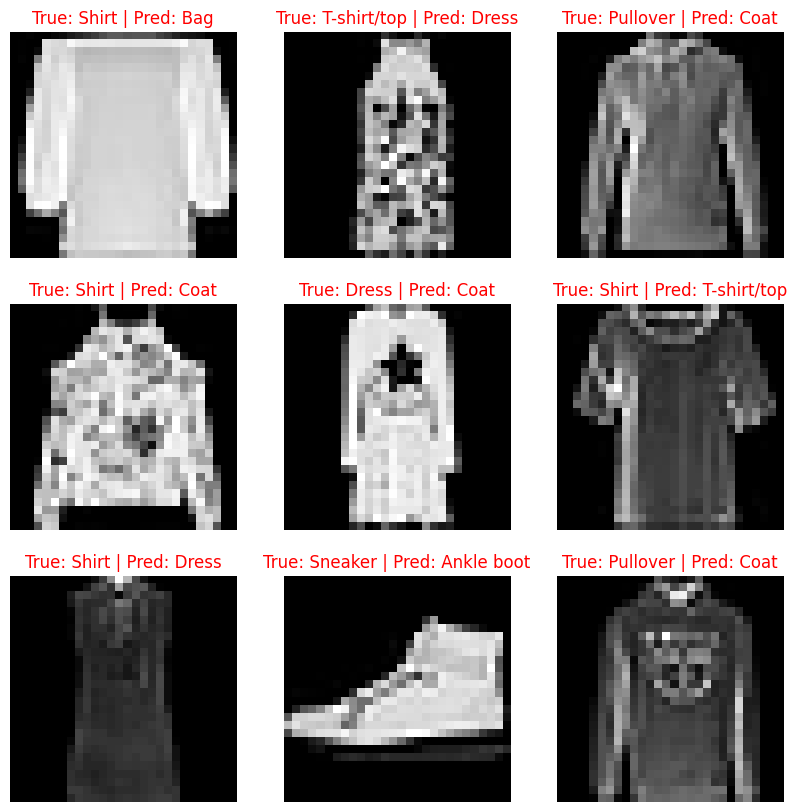

In [ ]:
# 틀린 예측 중 랜덤하게 9개를 선택하여 시각화
import random

# 1. 틀린 인덱스 리스트에서 무작위로 9개 추출
random_selection = random.sample(list(wrong_pred_indexes), k=9)

# 2. 9개의 이미지를 보여줄 전체 캔버스 설정 (10x10 크기)
plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_selection):
  # 3. 인덱스를 이용해 실제 정답 레이블과 모델의 예측 레이블 텍스트 가져오기
  true_label = fashion_mnist_class_names[fashion_mnist_test[idx][1]] # 실제 정답
  pred_label = fashion_mnist_class_names[test_preds[idx]]           # 모델의 오답

  # 4. 3x3 격자(Subplot) 설정
  plt.subplot(3, 3, i+1)

  # 5. 이미지 출력 (채널 차원 제거 후 흑백 처리)
  plt.imshow(fashion_mnist_test[idx][0].squeeze(), cmap="gray")

  # 6. 제목에 정답과 예측값을 표시 (오답임을 강조하기 위해 빨간색 'r' 설정)
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")

  # 7. 불필요한 축(axis) 숨기기
  plt.axis(False);

From the look of some of these predictions, the model is getting about as confused as I would...

For example it predicts "Sneaker" instead of "Sandal" when it could have easily been a "Sneaker".

The same goes for the confusion between the classes of "T-shirt/top" and "Shirt", many of the examples here look similar.